In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report, roc_auc_score, average_precision_score,
    confusion_matrix, RocCurveDisplay, PrecisionRecallDisplay
)
import xgboost as xgb

df = pd.read_csv("../data/processed/repeat_purchase_features.csv")
print(df.shape)
print(df['repeat_within_180d'].value_counts(normalize=True).round(4))

(55907, 17)
repeat_within_180d
0    0.972
1    0.028
Name: proportion, dtype: float64


C:\Temp\ipykernel_23928\3767717989.py:13: DtypeWarning: Columns (0: is_late_delivery) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("../data/processed/repeat_purchase_features.csv")


In [ ]:
df['has_review'] = df['review_score'].notna().astype(int)
df['review_score'] = df['review_score'].fillna(0)  

top_categories = df['primary_category'].value_counts().nlargest(10).index
df['category_grouped'] = df['primary_category'].where(df['primary_category'].isin(top_categories), 'other')

top_states = df['customer_state'].value_counts().nlargest(8).index
df['state_grouped'] = df['customer_state'].where(df['customer_state'].isin(top_states), 'other')

categorical_cols = ['category_grouped', 'primary_payment_type', 'state_grouped']
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

In [4]:
feature_cols = [c for c in df_encoded.columns if c not in [
    'customer_unique_id', 'first_order_id', 'first_purchase_date',
    'primary_category', 'customer_state', 'repeat_within_180d'
]]

X = df_encoded[feature_cols]
y = df_encoded['repeat_within_180d']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)
print(f"Train: {X_train.shape}, Positive rate: {y_train.mean():.4f}")
print(f"Test:  {X_test.shape}, Positive rate: {y_test.mean():.4f}")

Train: (41930, 32), Positive rate: 0.0280
Test:  (13977, 32), Positive rate: 0.0280


In [ ]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    class_weight='balanced',   
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

rf_proba = rf.predict_proba(X_test)[:, 1]
rf_pred = rf.predict(X_test)

print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, rf_proba):.4f}")
print(f"PR-AUC (Average Precision): {average_precision_score(y_test, rf_proba):.4f}")

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.98      0.75      0.85     13585
           1       0.04      0.33      0.07       392

    accuracy                           0.74     13977
   macro avg       0.51      0.54      0.46     13977
weighted avg       0.95      0.74      0.83     13977

ROC-AUC: 0.5784
PR-AUC (Average Precision): 0.0399


In [6]:
X_train['is_late_delivery'] = X_train['is_late_delivery'].astype(float)
X_test['is_late_delivery'] = X_test['is_late_delivery'].astype(float)

In [7]:
print(X_train['is_late_delivery'].isna().sum())
print(X_test['is_late_delivery'].isna().sum())

2
0


In [8]:
X_train['is_late_delivery'].value_counts(dropna=False)
X_test['is_late_delivery'].value_counts(dropna=False)

is_late_delivery
0.0    12925
1.0     1052
Name: count, dtype: int64

In [ ]:
neg, pos = np.bincount(y_train)
scale_pos_weight = neg / pos   

xgb_model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    scale_pos_weight=scale_pos_weight,
    eval_metric='aucpr',       
    random_state=42
)
xgb_model.fit(X_train, y_train)

xgb_proba = xgb_model.predict_proba(X_test)[:, 1]
xgb_pred = xgb_model.predict(X_test)

print("=== XGBoost ===")    
print(classification_report(y_test, xgb_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, xgb_proba):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, xgb_proba):.4f}")

=== XGBoost ===
              precision    recall  f1-score   support

           0       0.98      0.75      0.85     13585
           1       0.04      0.37      0.07       392

    accuracy                           0.74     13977
   macro avg       0.51      0.56      0.46     13977
weighted avg       0.95      0.74      0.82     13977

ROC-AUC: 0.5761
PR-AUC: 0.0390


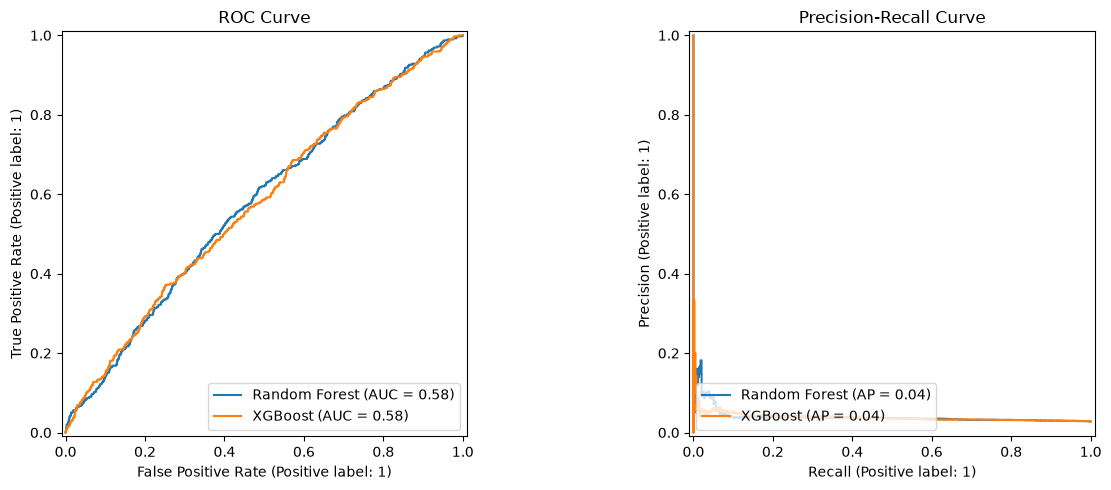

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
RocCurveDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=axes[0])
RocCurveDisplay.from_predictions(y_test, xgb_proba, name='XGBoost', ax=axes[0])
axes[0].set_title('ROC Curve')

PrecisionRecallDisplay.from_predictions(y_test, rf_proba, name='Random Forest', ax=axes[1])
PrecisionRecallDisplay.from_predictions(y_test, xgb_proba, name='XGBoost', ax=axes[1])
axes[1].set_title('Precision-Recall Curve')

plt.tight_layout()
plt.savefig('../reports/figures/11_model_comparison.png', dpi=150)
plt.show()

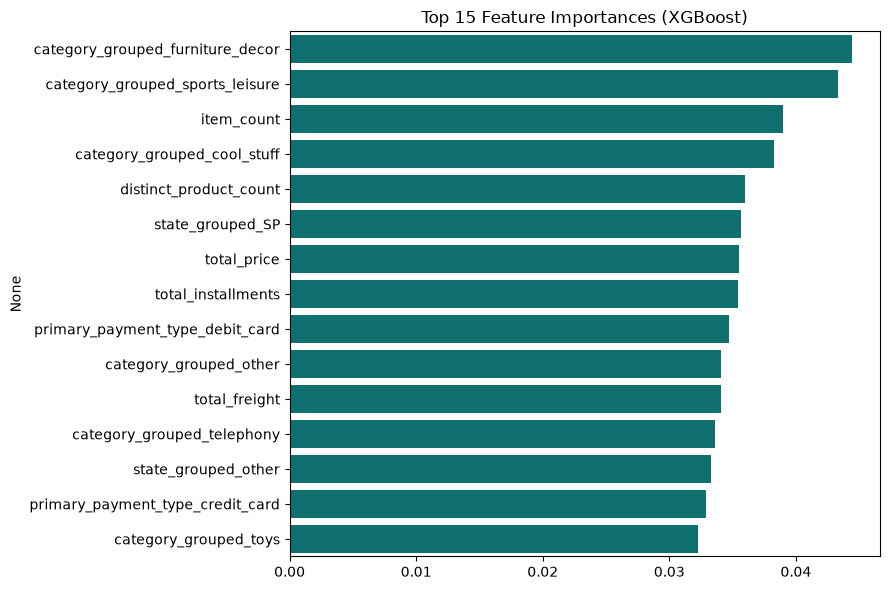

In [11]:
importances = pd.Series(xgb_model.feature_importances_, index=X.columns).sort_values(ascending=False).head(15)

plt.figure(figsize=(9, 6))
sns.barplot(x=importances.values, y=importances.index, color='teal')
plt.title('Top 15 Feature Importances (XGBoost)')
plt.tight_layout()
plt.savefig('../reports/figures/12_feature_importance.png', dpi=150)
plt.show()

In [12]:
import joblib
joblib.dump(xgb_model, '../models/churn_model.pkl')   # tên file giữ theo cấu trúc project ban đầu
print("Model saved.")

Model saved.


In [ ]:
results_df = pd.DataFrame({
    'y_true': y_test.values,
    'xgb_proba': xgb_proba
})

results_df['decile'] = pd.qcut(results_df['xgb_proba'], 10, labels=False, duplicates='drop')

baseline_rate = results_df['y_true'].mean()

lift_table = results_df.groupby('decile').agg(
    avg_predicted_proba=('xgb_proba', 'mean'),
    actual_repeat_rate=('y_true', 'mean'),
    n_customers=('y_true', 'count')
).sort_index(ascending=False)

lift_table['lift_vs_baseline'] = (lift_table['actual_repeat_rate'] / baseline_rate).round(2)
print(lift_table)

        avg_predicted_proba  actual_repeat_rate  n_customers  lift_vs_baseline
decile                                                                        
9                  0.633408            0.040773         1398              1.45
8                  0.549478            0.040057         1398              1.43
7                  0.502723            0.030780         1397              1.10
6                  0.463612            0.027897         1398              0.99
5                  0.430838            0.024338         1397              0.87
4                  0.397752            0.032904         1398              1.17
3                  0.360802            0.025036         1398              0.89
2                  0.319205            0.020759         1397              0.74
1                  0.262339            0.022175         1398              0.79
0                  0.154380            0.015737         1398              0.56


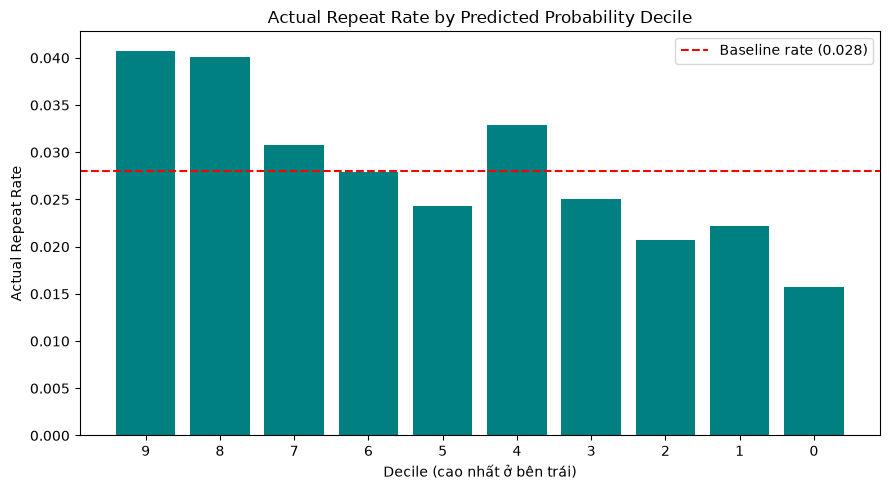

In [14]:
plt.figure(figsize=(9, 5))
plt.bar(lift_table.index.astype(str), lift_table['actual_repeat_rate'], color='teal')
plt.axhline(baseline_rate, color='red', linestyle='--', label=f'Baseline rate ({baseline_rate:.3f})')
plt.title('Actual Repeat Rate by Predicted Probability Decile')
plt.xlabel('Decile (cao nhất ở bên trái)')
plt.ylabel('Actual Repeat Rate')
plt.legend()
plt.tight_layout()
plt.savefig('../reports/figures/13_lift_chart.png', dpi=150)
plt.show()

In [15]:
from scipy import stats

top20 = results_df[results_df['decile'].isin([8, 9])]
rest = results_df[~results_df['decile'].isin([8, 9])]

p1, n1 = top20['y_true'].mean(), len(top20)
p2, n2 = rest['y_true'].mean(), len(rest)
p_pool = (top20['y_true'].sum() + rest['y_true'].sum()) / (n1 + n2)
se = (p_pool * (1 - p_pool) * (1/n1 + 1/n2)) ** 0.5
z = (p1 - p2) / se
p_value = 2 * (1 - stats.norm.cdf(abs(z)))

print(f"Top 20% repeat rate: {p1:.4f} | Rest: {p2:.4f} | z={z:.2f} | p-value={p_value:.4f}")

Top 20% repeat rate: 0.0404 | Rest: 0.0250 | z=4.43 | p-value=0.0000


In [ ]:
from sklearn.model_selection import RandomizedSearchCV, StratifiedKFold

param_dist = {
    'max_depth': [3, 4, 5, 6, 7],
    'learning_rate': [0.01, 0.03, 0.05, 0.1, 0.2],
    'n_estimators': [100, 200, 300, 500],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'min_child_weight': [1, 3, 5, 10],
    'scale_pos_weight': [scale_pos_weight * f for f in [0.5, 1.0, 1.5, 2.0]],
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

search = RandomizedSearchCV(
    estimator=xgb.XGBClassifier(eval_metric='aucpr', random_state=42),
    param_distributions=param_dist,
    n_iter=30,                    
    scoring='average_precision',    
    cv=cv,
    random_state=42,
    n_jobs=-1,
    verbose=1
)

search.fit(X_train, y_train)

print("Best params:", search.best_params_)
print("Best CV PR-AUC:", round(search.best_score_, 4))

Fitting 5 folds for each of 30 candidates, totalling 150 fits
Best params: {'subsample': 1.0, 'scale_pos_weight': np.float64(52.07325383304941), 'n_estimators': 200, 'min_child_weight': 5, 'max_depth': 3, 'learning_rate': 0.05, 'colsample_bytree': 1.0}
Best CV PR-AUC: 0.0458


In [17]:
best_model = search.best_estimator_
best_proba = best_model.predict_proba(X_test)[:, 1]
best_pred = best_model.predict(X_test)

print(classification_report(y_test, best_pred))
print(f"ROC-AUC: {roc_auc_score(y_test, best_proba):.4f}")
print(f"PR-AUC: {average_precision_score(y_test, best_proba):.4f}")

              precision    recall  f1-score   support

           0       0.98      0.25      0.40     13585
           1       0.03      0.84      0.06       392

    accuracy                           0.27     13977
   macro avg       0.51      0.54      0.23     13977
weighted avg       0.96      0.27      0.39     13977

ROC-AUC: 0.5794
PR-AUC: 0.0391


In [18]:
results_tuned = pd.DataFrame({'y_true': y_test.values, 'proba': best_proba})
results_tuned['decile'] = pd.qcut(results_tuned['proba'], 10, labels=False, duplicates='drop')

baseline_rate = results_tuned['y_true'].mean()
lift_tuned = results_tuned.groupby('decile').agg(
    actual_repeat_rate=('y_true', 'mean'),
    n=('y_true', 'count')
).sort_index(ascending=False)
lift_tuned['lift_vs_baseline'] = (lift_tuned['actual_repeat_rate'] / baseline_rate).round(2)

print(lift_tuned)
print(f"\nLift top 20% (tuned) vs top 20% (untuned ~1.44x):")
print(lift_tuned.iloc[:2]['lift_vs_baseline'].mean())

        actual_repeat_rate     n  lift_vs_baseline
decile                                            
9                 0.041488  1398              1.48
8                 0.039342  1398              1.40
7                 0.033644  1397              1.20
6                 0.026466  1398              0.94
5                 0.031496  1397              1.12
4                 0.024320  1398              0.87
3                 0.021459  1398              0.77
2                 0.025770  1397              0.92
1                 0.020029  1398              0.71
0                 0.016452  1398              0.59

Lift top 20% (tuned) vs top 20% (untuned ~1.44x):
1.44


In [ ]:
lift_export = lift_tuned.reset_index()  
lift_export.to_csv('../data/processed/model_lift_deciles.csv', index=False)

importances_export = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15).reset_index()
importances_export.columns = ['feature', 'importance']
importances_export.to_csv('../data/processed/feature_importance.csv', index=False)

print("Đã export lift table và feature importance.")

Đã export lift table và feature importance.


In [20]:
def clean_feature_name(name):
    prefix_map = {
        'category_grouped_': 'Category: ',
        'state_grouped_': 'State: ',
        'primary_payment_type_': 'Payment: ',
    }
    for prefix, label in prefix_map.items():
        if name.startswith(prefix):
            value = name[len(prefix):].replace('_', ' ').title()
            return f"{label}{value}"

    manual_labels = {
        'item_count': 'Item Count',
        'distinct_product_count': 'Distinct Product Count',
        'total_price': 'Order Value (R$)',
        'total_freight': 'Freight Value (R$)',
        'total_installments': 'Payment Installments',
        'delivery_days': 'Delivery Days',
        'is_late_delivery': 'Late Delivery',
        'review_score': 'Review Score',
        'has_review': 'Has Review',
        'purchase_month': 'Purchase Month',
        'purchase_dow': 'Purchase Day of Week',
    }
    return manual_labels.get(name, name.replace('_', ' ').title())


importances_export = pd.Series(
    best_model.feature_importances_, index=X.columns
).sort_values(ascending=False).head(15).reset_index()
importances_export.columns = ['feature', 'importance']
importances_export['feature_label'] = importances_export['feature'].apply(clean_feature_name)

importances_export.to_csv('../data/processed/feature_importance.csv', index=False)
print(importances_export[['feature_label', 'importance']])

                      feature_label  importance
0         Category: Furniture Decor    0.054997
1            Distinct Product Count    0.046101
2                     Late Delivery    0.045030
3               Payment: Debit Card    0.044190
4           Category: Watches Gifts    0.041877
5   Category: Computers Accessories    0.041795
6                   Category: Other    0.040283
7                         State: Rj    0.039550
8                        Item Count    0.038664
9              Category: Cool Stuff    0.037965
10             Payment Installments    0.037070
11                        State: Pr    0.036236
12                 Order Value (R$)    0.033904
13         Category: Sports Leisure    0.033414
14             Purchase Day of Week    0.031882
